In [1]:
import numpy as np
import matplotlib.pyplot as plt
from herculens.Coordinates.pixel_grid import PixelGrid
from herculens.Instrument.noise import Noise
from herculens.Instrument.psf import PSF
from herculens.MassModel.mass_model import MassModel
from herculens.LightModel.light_model import LightModel
from herculens.LensImage.lens_image import LensImage

/opt/anaconda3/envs/herculensenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


I want a function which can do all the hard work of initialising hubble, euclid and jwst images for me

In [2]:
def initialise_lens_simulation(exposure_time=600, fov=2.0, telescope="hubble"):
    """
    Initialise a lens simulation corresponding to that of a certain telescope
    """
    RES = {'hubble': 0.04, 'euclid': 0.1, 'JWST': 0.063} # arcseconds
    NOISE = {'hubble': 8.7e-3, 'euclid': 4.2e-3, 'JWST': 15.8e-3} # e- rms (downscaled by a factor of 1000 for signal-to-noise)
    PSF_FILE = {# (filename, supersampling factor)
    'hubble': ('hubble_psf.npy', 4), 
    'euclid': ('euclid_psf.npy', 1),
    'JWST': ('JWST_psf.npy', 7)
    }

    pix_scale = RES[telescope]
    noise = NOISE[telescope]
    psf_filename, supersampling_factor = PSF_FILE[telescope]
    psf = np.load(f"psf/{psf_filename}")

    nx, ny = (int(np.floor(fov/pix_scale)), int(np.floor(fov/pix_scale)))

    # set central pixel to (0,0)
    half_size_x = nx // 2
    half_size_y = ny // 2
    ra_at_xy_0 = - half_size_x * pix_scale
    dec_at_xy_0 = - half_size_y * pix_scale

    transform_pix2angle = pix_scale*np.eye(2)
    kwargs_pixel = {
        'nx': nx,
        'ny': ny,
        'ra_at_xy_0': ra_at_xy_0,
        'dec_at_xy_0': dec_at_xy_0,
        'transform_pix2angle': transform_pix2angle
    }

    # herculens' pixel grid class handles everything
    pixel_grid = PixelGrid(**kwargs_pixel)

    noise = Noise(nx, ny, background_rms=noise, exposure_time=exposure_time)
    psf = PSF(
        psf_type='PIXEL', 
        pixel_size=pix_scale, 
        kernel_point_source=psf, 
        kernel_supersampling_factor=supersampling_factor
        )
    
    return pixel_grid, noise, psf

In [3]:
signal_to_noise=100
telescope='JWST'
pixel_grid, noise, psf = initialise_lens_simulation(telescope=telescope)

# useful things we might need from it
xgrid, ygrid = pixel_grid.pixel_coordinates
x_axis = xgrid[0]
y_axis = ygrid[:, 0]
extent = pixel_grid.extent
x_grid, y_grid = np.meshgrid(x_axis, y_axis)   

In [4]:
lens_mass_model = MassModel(['EPL', 'SHEAR']) # add deflection angles together: elliptical power law with external shear
lens_light_model = LightModel(['SERSIC_ELLIPSE']) # elliptical sersic profile
source_light_model = LightModel(['SERSIC_ELLIPSE']) 

In [5]:
lens_EPL_kwargs = {
    'theta_E': 0.6,
    'gamma': 2.05,
    'e1': 0.3,
    'e2': 0.2,
    'center_x': 0.0,
    'center_y': 0.0
}
lens_shear_kwargs = {
    'gamma1': 0.0,
    'gamma2': -0.03,
    'ra_0': lens_EPL_kwargs['center_x'],    # center external shear on lens
    'dec_0': lens_EPL_kwargs['center_y'],   # center external shear on lens
}
lens_mass_kwargs = [lens_EPL_kwargs, lens_shear_kwargs]

# convergence
lens_kappa = lens_mass_model.kappa(x=x_grid, y=y_grid, kwargs=lens_mass_kwargs)

# shear
lens_gamma = lens_mass_model.gamma(x=x_grid, y=y_grid, kwargs=lens_mass_kwargs)
lens_gamma_1, lens_gamma_2 = lens_gamma

# deflection angle
lens_alpha = lens_mass_model.alpha(x=x_grid, y=y_grid, kwargs=lens_mass_kwargs)
lens_alpha_x, lens_alpha_y = lens_alpha

# light profiles

lens_sersic_kwargs = {
    'amp': signal_to_noise * 1.0,
    'R_sersic': 0.15,
    'n_sersic': 4.0, # n=4: de Vaucouleurs profile
    'e1': 0.3,
    'e2': 0.2,
    'center_x': 0.0,
    'center_y': 0.0
}

lens_light_kwargs = [lens_sersic_kwargs]

source_sersic_kwargs = {
    'amp': signal_to_noise * 1.0,
    'R_sersic': 0.04,
    'n_sersic': 1.0, # n=1: exponential profile
    'e1': 0.0,
    'e2': 0.1,
    'center_x': 0.01,
    'center_y': 0.04
}

source_light_kwargs = [source_sersic_kwargs]

lens_light_prof = lens_light_model.surface_brightness(x=x_grid, y=y_grid, kwargs=lens_light_kwargs)
source_light_prof = source_light_model.surface_brightness(x=x_grid, y=y_grid, kwargs=source_light_kwargs) 

In [6]:
ss = 10

# handles stuff that needs ray tracing
lens_image = LensImage(
    grid_class=pixel_grid,
    psf_class=psf,
    noise_class=noise,
    lens_mass_model_class=lens_mass_model,
    lens_light_model_class=lens_light_model,
    source_model_class=source_light_model,
    kwargs_numerics={"supersampling_factor" : ss}
)

In [7]:
model_image = lens_image.model(
    kwargs_lens=lens_mass_kwargs, 
    kwargs_source=source_light_kwargs, 
    kwargs_lens_light=lens_light_kwargs, 
    supersampled=True,
    point_source_add=False
    ).reshape(31*ss, 31*ss)

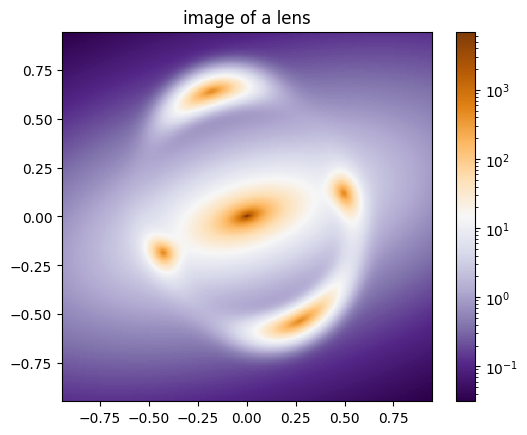

In [8]:
plt.imshow(model_image, origin='lower', cmap='PuOr_r',  extent=extent, norm='log')
plt.colorbar()
plt.title(f'image of a lens')
plt.savefig(f"figures_out/image.png")
plt.show()

In [9]:
simulation_image = lens_image.simulation(
    kwargs_lens=lens_mass_kwargs, 
    kwargs_source=source_light_kwargs, 
    kwargs_lens_light=lens_light_kwargs, 
    unconvolved=False
    )

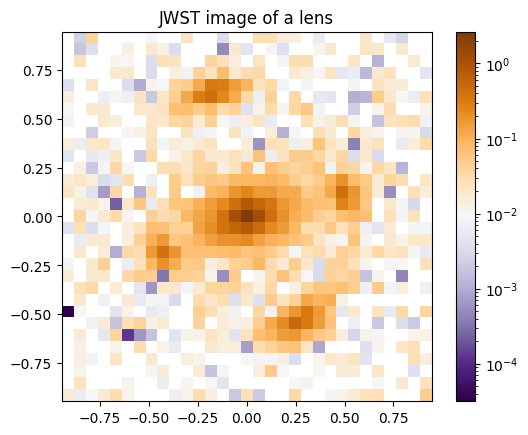

In [10]:
plt.imshow(simulation_image, origin='lower', cmap='PuOr_r',  extent=extent, norm='log')
plt.colorbar()
plt.title(f'{telescope} image of a lens')
plt.savefig(f"figures_out/{telescope}_image.png")
plt.show()